# Single-Node Baseline Fine-Tuning

Single-node LoRA fine-tune of Phi-2 on 2,000 Alpaca samples for 3 epochs.
Identical LoRA config to the distributed run (r=16, alpha=32).

**This is the quality ceiling for the distributed system. No coordination overhead.**

Nothing is pushed to the shared Hub repo. Adapter saved locally/Google Drive only.

**Before running:** Runtime > Change runtime type > T4 GPU

## Section 0 — Install & Imports

In [1]:
!pip install -q -U huggingface-hub transformers peft datasets accelerate safetensors matplotlib
!pip install -q -U torchao
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 112.9 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/madch3m/peft-distributed.git /content/peft-distributed
import sys
sys.path.insert(0, "/content/peft-distributed")

Cloning into '/content/peft-distributed'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 198 (delta 106), reused 164 (delta 72), pack-reused 0 (from 0)
Receiving objects: 100% (198/198), 70.58 KiB | 5.43 MiB/s, done.
Resolving deltas: 100% (106/106), done.


In [3]:
import os
import json
import time
import copy
from collections import defaultdict

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, PeftModel
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_download, upload_file, upload_folder
from safetensors.torch import load_file, save_file

print(f"torch {torch.__version__}  CUDA {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch 2.10.0+cu128  CUDA True
GPU: Tesla T4


## Section 1 — CONFIG

**Fill in your HF token before running. All other values are pre-set for the baseline.**

Key differences from the distributed config:
- `layer_start=0, layer_end=31` — this node owns ALL layers
- `batch_size=2, grad_accum_steps=8` — effective batch 16, matching A100
- `num_rounds=3` — treated as 3 training epochs
- No aggregator URL or node secret needed

In [ ]:
REPO_ID = "Dev-the-dev91/instruction-fine-tuning-budget"

CONFIG = {
    # === Identity — single node owns all layers ===
    "node_id": "node_a",
    "layer_start": 0,
    "layer_end": 31,          # owns ALL layers for single-node baseline

    # === HuggingFace Hub ===
    "hf_token": "",  # Fill in your token
    "repo_id": REPO_ID,
    "hub_create_repo": False,      # repo already exists

    # === Aggregator — not used for baseline ===
    "aggregator_url": "",
    "node_secret": "",
    "status_read_secret": "",

    # === LoRA — identical to distributed run ===
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "v_proj", "k_proj", "dense", "fc1", "fc2"],

    # === Training ===
    "base_model": "microsoft/phi-2",
    "max_seq_len": 512, #changed from 512
    "batch_size": 2,               # T4 limit
    "grad_accum_steps": 8,         # effective batch = 16, matching A100 config
    "num_rounds": 3,               # 3 passes through data = 3 epochs
    "steps_per_round": 1000,       # 2000 samples / batch_size 2 = ~1000 steps/epoch
    "learning_rate": 2e-4,

    # === Async gradient exchange — disabled for baseline ===
    "grad_sync_every_n_steps": 99999,  # effectively never
    "remote_grad_lr": 0.5,
    "grad_staleness_threshold": 3,
}

os.environ["HF_TOKEN"] = CONFIG["hf_token"]
from huggingface_hub import HfApi
api = HfApi(token=CONFIG["hf_token"])

print(f"Node: {CONFIG['node_id']}  Layers: {CONFIG['layer_start']}-{CONFIG['layer_end']}")
print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")
print(f"Steps per epoch: {CONFIG['steps_per_round']}")
print(f"Total epochs: {CONFIG['num_rounds']}")


Node: node_a  Layers: 0-31
Effective batch size: 16
Steps per epoch: 1000
Total epochs: 3


## Section 3 — Dataset

Load and tokenize Alpaca 2K (or domain-specific dataset).

In [5]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model"], trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load dataset — default: Alpaca
hf_path = CONFIG.get("hf_path", "tatsu-lab/alpaca")
raw = load_dataset(hf_path, split="train")

# Normalise to {text} format
def normalise(example):
    instruction = (
        example.get("instruction")
        or example.get("question")
        or example.get("input", "")
    )
    response = (
        example.get("output")
        or example.get("answer")
        or example.get("response", "")
    )
    return {"text": f"### Instruction:\n{instruction}\n\n### Response:\n{response}"}

dataset = raw.map(normalise).select(range(min(2000, len(raw))))

# Tokenize
def tokenize(example):
    out = tokenizer(
        example["text"],
        truncation=True,
        max_length=CONFIG["max_seq_len"],
        padding="max_length",
    )
    out["labels"] = out["input_ids"].copy()
    return out

tokenized = dataset.map(tokenize, remove_columns=dataset.column_names)
tokenized.set_format("torch")

dataloader = DataLoader(tokenized, batch_size=CONFIG["batch_size"], shuffle=True)
print(f"Dataset: {len(tokenized)} samples, {len(dataloader)} batches")

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Map:   0%|          | 0/52002 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset: 2000 samples, 1000 batches


## Section 4 — Model + LoRA

Load Phi-2, attach LoRA adapters, freeze base weights.

In [6]:
import gc

# Free any leftover GPU memory from prior runs
gc.collect()
torch.cuda.empty_cache()

# Load base model — newer transformers expects config.pad_token_id; Phi-2 config may omit it
model_config = AutoConfig.from_pretrained(
    CONFIG["base_model"],
    trust_remote_code=True,
)
_pad = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
if getattr(model_config, "pad_token_id", None) is None:
    try:
        model_config.pad_token_id = _pad
    except AttributeError:
        object.__setattr__(model_config, "pad_token_id", _pad)

# PyTorch SDPA — built-in, no extra install, near flash-attn performance on A100
print("Using PyTorch SDPA attention (built-in)")

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["base_model"],
    config=model_config,
    # torch_dtype=torch.bfloat16,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

# Attach LoRA
lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=CONFIG["target_modules"],
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Freeze/unfreeze based on layer partition
owned_params = []
for name, param in model.named_parameters():
    if "lora_" in name:
        # Extract layer number from parameter name
        layer_num = None
        for part in name.split("."):
            if part.isdigit():
                layer_num = int(part)
                break

        if layer_num is not None and CONFIG["layer_start"] <= layer_num <= CONFIG["layer_end"]:
            param.requires_grad = True
            owned_params.append((name, param))
        else:
            param.requires_grad = False

print(f"\nOwned adapter params: {len(owned_params)}")
total_owned = sum(p.numel() for _, p in owned_params)
print(f"Owned trainable parameters: {total_owned:,}")

# Report GPU memory after model load
if torch.cuda.is_available():
    alloc = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"GPU memory: {alloc:.1f} GB allocated, {reserved:.1f} GB reserved")

Using PyTorch SDPA attention (built-in)


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 23,592,960 || all params: 2,803,276,800 || trainable%: 0.8416

Owned adapter params: 384
Owned trainable parameters: 23,592,960
GPU memory: 5.7 GB allocated, 5.7 GB reserved


## Section 5 — Gradient Hooks

Register hooks on owned adapter parameters to capture gradients for async exchange.

In [7]:
grad_buffer = {}
hook_handles = []

def register_hooks():
    """Register backward hooks on owned LoRA params to accumulate gradients."""
    global hook_handles
    # Clear existing hooks
    for h in hook_handles:
        h.remove()
    hook_handles = []
    grad_buffer.clear()

    for name, param in owned_params:
        grad_buffer[name] = torch.zeros_like(param.data)

        def make_hook(param_name):
            def hook_fn(grad):
                grad_buffer[param_name] += grad.detach().clone()
            return hook_fn

        handle = param.register_hook(make_hook(name))
        hook_handles.append(handle)

    print(f"Registered {len(hook_handles)} gradient hooks.")

register_hooks()

Registered 384 gradient hooks.


## Section 6 — Optimizer

AdamW on owned params only.

In [8]:
optimizer = torch.optim.AdamW(
    [p for _, p in owned_params],
    lr=CONFIG["learning_rate"],
    weight_decay=0.01,
)

print(f"Optimizer: AdamW, lr={CONFIG['learning_rate']}, params={len(owned_params)}")

Optimizer: AdamW, lr=0.0002, params=384


## Section 7 — Training Loop

Standard forward/backward/grad-accum loop. No Hub pushes, no aggregator calls, no async gradient exchange.

Each `num_rounds` iteration is one full pass (epoch) over the dataset.
Adapter saved locally to `/content/baseline_adapter` after all epochs complete.

In [9]:
# Baseline training loop — no Hub interaction, no aggregator
loss_history = []
epoch_avg_losses = []

import time
start_time = time.time()

for current_round in range(1, CONFIG["num_rounds"] + 1):
    print(f"\n{'='*60}")
    print(f"EPOCH {current_round}/{CONFIG['num_rounds']}")
    print(f"{'='*60}")

    model.train()
    data_iter = iter(dataloader)
    round_losses = []
    optimizer.zero_grad()

    for step in range(1, CONFIG["steps_per_round"] + 1):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(model.device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss / CONFIG["grad_accum_steps"]
        loss.backward()

        if step % CONFIG["grad_accum_steps"] == 0:
            optimizer.step()
            optimizer.zero_grad()

        round_losses.append(loss.item() * CONFIG["grad_accum_steps"])

        if step % 50 == 0:
            elapsed = (time.time() - start_time) / 60
            avg = np.mean(round_losses[-20:])
            print(f"  Step {step}/{CONFIG['steps_per_round']}  "
                  f"loss={avg:.4f}  elapsed={elapsed:.1f}min")

    avg_loss = float(np.mean(round_losses))
    epoch_avg_losses.append(avg_loss)
    loss_history.extend(round_losses)
    print(f"Epoch {current_round} avg loss: {avg_loss:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining complete in {total_time:.1f} minutes")

# Save locally — nothing pushed to Hub
import os
BASELINE_SAVE_PATH = "/content/baseline_adapter"
os.makedirs(BASELINE_SAVE_PATH, exist_ok=True)
model.save_pretrained(BASELINE_SAVE_PATH)
tokenizer.save_pretrained(BASELINE_SAVE_PATH)
print(f"Baseline adapter saved to {BASELINE_SAVE_PATH}")
print("NOTE: Nothing was pushed to the Hub.")



EPOCH 1/3
  Step 50/1000  loss=2.9704  elapsed=0.9min
  Step 100/1000  loss=0.3504  elapsed=1.9min
  Step 150/1000  loss=0.4726  elapsed=2.9min
  Step 200/1000  loss=0.3590  elapsed=3.8min
  Step 250/1000  loss=0.3480  elapsed=4.8min
  Step 300/1000  loss=0.3021  elapsed=5.8min
  Step 350/1000  loss=0.3463  elapsed=6.7min
  Step 400/1000  loss=0.3117  elapsed=7.7min
  Step 450/1000  loss=0.3096  elapsed=8.7min
  Step 500/1000  loss=0.3152  elapsed=9.6min
  Step 550/1000  loss=0.3114  elapsed=10.6min
  Step 600/1000  loss=0.3035  elapsed=11.6min
  Step 650/1000  loss=0.2765  elapsed=12.5min
  Step 700/1000  loss=0.2277  elapsed=13.5min
  Step 750/1000  loss=0.2309  elapsed=14.5min
  Step 800/1000  loss=0.2499  elapsed=15.4min
  Step 850/1000  loss=0.2172  elapsed=16.4min
  Step 900/1000  loss=0.2520  elapsed=17.3min
  Step 950/1000  loss=0.2428  elapsed=18.3min
  Step 1000/1000  loss=0.2244  elapsed=19.3min
Epoch 1 avg loss: 0.5246

EPOCH 2/3
  Step 50/1000  loss=0.2440  elapsed=20.2mi

## Section 8 — Round-End Sync

Round-end sync is built into the **Section 7** training cell (`round_end_sync` + per-round `notify_aggregator`). Use the optional cell below only for **manual** replay after an error.


In [ ]:
# Not needed for baseline — round_end_sync is not used.
print("Section 8 not applicable for baseline run.")

Section 8 not applicable for baseline run.


## Section 8b — Save Adapter to Google Drive

Run this immediately after training to persist the adapter before the Colab session disconnects.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, json

# Save adapter weights
shutil.copytree(
    '/content/baseline_adapter',
    '/content/drive/MyDrive/peft_baseline_adapter',
    dirs_exist_ok=True
)
print('Adapter saved to Google Drive: MyDrive/peft_baseline_adapter')

# Save training stats alongside adapter
stats = {
    'epoch_avg_losses': epoch_avg_losses,
    'round_avgs': epoch_avg_losses,
    'loss_history': loss_history,
    'steps_per_round': CONFIG['steps_per_round'],
    'num_rounds': CONFIG['num_rounds'],
}
with open('/content/drive/MyDrive/baseline_training_stats.json', 'w') as f:
    json.dump(stats, f)
print('Training stats saved to Google Drive: MyDrive/baseline_training_stats.json')


Mounted at /content/drive
Adapter saved to Google Drive: MyDrive/peft_baseline_adapter
Training stats saved to Google Drive: MyDrive/baseline_training_stats.json


## Section 9 — Evaluation

Instruction-following accuracy on held-out prompts.

In [11]:
eval_prompts = [
    "### Instruction:\nExplain photosynthesis in three sentences.\n\n### Response:\n",
    "### Instruction:\nList 5 benefits of regular exercise.\n\n### Response:\n",
    "### Instruction:\nWrite a Python function to check if a number is prime.\n\n### Response:\n",
    "### Instruction:\nWhat is the capital of France? Answer in one word.\n\n### Response:\n",
    "### Instruction:\nSummarize the theory of relativity for a 10-year-old.\n\n### Response:\n",
]

model.eval()
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

for prompt in eval_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"\n{'─'*40}")
    print(response)
    print()


EVALUATION

────────────────────────────────────────
### Instruction:
Explain photosynthesis in three sentences.

### Response:
Photosynthesis is the process by which plants, algae and some bacteria use sunlight, carbon dioxide and water to produce glucose (sugar) and oxygen. The process occurs in the leaves of plants, where the green pigment chlorophyll absorbs sunlight and converts it into energy to power the chemical reaction. This process is essential for the survival of plants and the production of oxygen for other organisms.


────────────────────────────────────────
### Instruction:
List 5 benefits of regular exercise.

### Response:
1. Improved cardiovascular health: Regular exercise can help strengthen the heart and reduce the risk of heart disease.

2. Weight management: Exercise can help burn calories and maintain a healthy weight.

3. Increased energy: Regular exercise can help improve energy levels and reduce fatigue.

4. Improved mood: Exercise has been shown to increase

## Section 10 — Plots

Loss curves and round history.

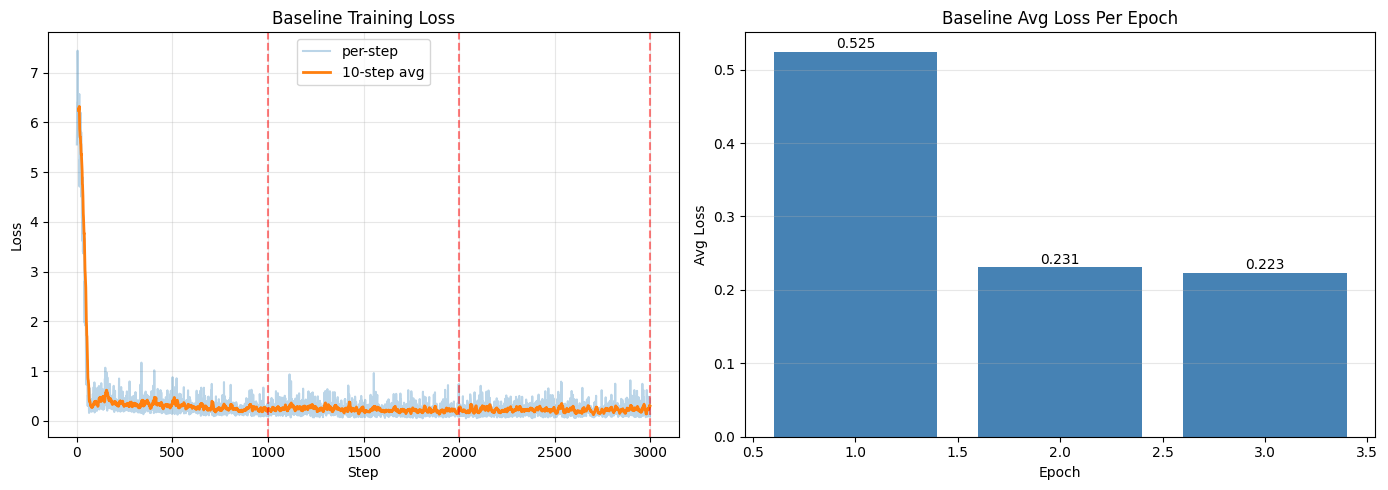

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plot saved to Drive.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history, alpha=0.3, label='per-step')
window = 10
if len(loss_history) >= window:
    smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(loss_history)), smoothed,
                 label=f'{window}-step avg', linewidth=2)
steps_per_round = CONFIG['steps_per_round']
for r in range(1, CONFIG['num_rounds'] + 1):
    axes[0].axvline(x=r * steps_per_round, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Baseline Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

round_avgs = epoch_avg_losses
axes[1].bar(range(1, len(round_avgs) + 1), round_avgs, color='steelblue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg Loss')
axes[1].set_title('Baseline Avg Loss Per Epoch')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(round_avgs):
    axes[1].text(i+1, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
LOCAL_PLOT = '/content/baseline_training_plots.png'
plt.savefig(LOCAL_PLOT, dpi=150)
plt.show()

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import shutil
shutil.copy(LOCAL_PLOT, '/content/drive/MyDrive/peft_baseline_training_plots.png')
print('Plot saved to Drive.')


## Section 11 — Load Baseline Model from Google Drive

 Reload the baseline without retraining - redundant with above if running end to end

In [ ]:
import gc, os, shutil, json, torch
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from peft import LoraConfig, get_peft_model
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import numpy as np

drive.mount('/content/drive', force_remount=False)

# Load training stats
with open('/content/drive/MyDrive/baseline_training_stats.json') as f:
    stats = json.load(f)
epoch_avg_losses = stats['epoch_avg_losses']
round_avgs       = stats['round_avgs']
loss_history     = stats['loss_history']
print(f'Training stats loaded. Epoch losses: {epoch_avg_losses}')

# Copy adapter from Drive
shutil.copytree(
    '/content/drive/MyDrive/peft_baseline_adapter',
    '/content/baseline_adapter_loaded',
    dirs_exist_ok=True
)

# Load model
tokenizer = AutoTokenizer.from_pretrained('microsoft/phi-2', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    'microsoft/phi-2',
    torch_dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'dense', 'fc1', 'fc2'],
    bias='none', task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_cfg)

saved_state = load_file('/content/baseline_adapter_loaded/adapter_model.safetensors')
model_params = dict(model.named_parameters())
loaded_count = 0
for key, tensor in saved_state.items():
    if key in model_params:
        model_params[key].data.copy_(tensor.to(model_params[key].device))
        loaded_count += 1
print(f'Loaded {loaded_count} adapter params. Baseline model ready.')


## Section 11b — Baseline Eval Prompts

In [ ]:
import torch

eval_prompts = [
    '### Instruction:\nExplain photosynthesis in three sentences.\n\n### Response:\n',
    '### Instruction:\nList 5 benefits of regular exercise.\n\n### Response:\n',
    '### Instruction:\nWrite a Python function to check if a number is prime.\n\n### Response:\n',
    '### Instruction:\nWhat is the capital of France? Answer in one word.\n\n### Response:\n',
    '### Instruction:\nSummarize the theory of relativity for a 10-year-old.\n\n### Response:\n',
]
prompt_labels = [
    'Explain photosynthesis in three sentences',
    'List 5 benefits of regular exercise',
    'Write a Python prime function',
    'What is the capital of France',
    'Summarize relativity for a 10-year-old',
]

model.eval()
responses = []

print('\n' + '='*70)
print('BASELINE EVALUATION')
print('='*70)

for i, prompt in enumerate(eval_prompts):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3,
        )
    full = tokenizer.decode(output[0], skip_special_tokens=True)
    resp = full.split('### Response:')[-1].strip()
    responses.append(resp)
    print(f'\n{chr(9472)*70}')
    print(f'PROMPT {i+1}: {prompt_labels[i]}')
    print(f'{chr(9472)*70}')
    print(resp)

baseline_responses = responses


## Section 11c — Baseline Loss Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if loss_history:
    axes[0].plot(loss_history, alpha=0.3, label='per-step')
    window = 10
    if len(loss_history) >= window:
        smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(loss_history)), smoothed,
                     label=f'{window}-step avg', linewidth=2)
    steps_per_round = len(loss_history) // len(round_avgs)
    for r in range(1, len(round_avgs) + 1):
        axes[0].axvline(x=r * steps_per_round, color='red', linestyle='--', alpha=0.5)
else:
    axes[0].text(0.5, 0.5, 'Step-level history not available', ha='center', va='center',
                 transform=axes[0].transAxes)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Baseline Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, len(round_avgs) + 1), round_avgs, color='steelblue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg Loss')
axes[1].set_title('Baseline Avg Loss Per Epoch')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(round_avgs):
    axes[1].text(i+1, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
LOCAL_PLOT = '/content/baseline_loss.png'
plt.savefig(LOCAL_PLOT, dpi=150)
plt.show()

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import shutil
shutil.copy(LOCAL_PLOT, '/content/drive/MyDrive/baseline_loss.png')
print('Plot saved to Drive.')


## Section 11d — Free GPU Before Loading Federated Model

In [13]:
import gc
del model
gc.collect()
torch.cuda.empty_cache()
print(f'Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'Reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB')
print('GPU free. Ready to load federated model.')


Allocated: 0.84 GB
Reserved:  2.29 GB
GPU free. Ready to load federated model.


## Section 12 — Load Federated Model from Hub

In [14]:
import gc, os, json, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

_repo  = CONFIG.get('repo_id', REPO_ID)
_token = CONFIG.get('hf_token', os.environ.get('HF_TOKEN', ''))

# Find latest merged round
_state_path = hf_hub_download(repo_id=_repo, filename='aggregator_state.json', token=_token)
with open(_state_path) as f:
    _hub_state = json.load(f)
latest_round = _hub_state['current_round'] - 1
print(f'Latest merged round: {latest_round}')

tokenizer = AutoTokenizer.from_pretrained('microsoft/phi-2', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    'microsoft/phi-2',
    torch_dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'dense', 'fc1', 'fc2'],
    bias='none', task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_cfg)

merged_path = hf_hub_download(
    repo_id=_repo,
    filename=f'merged/round_{latest_round}/adapter_model.safetensors',
    token=_token,
)
merged_state = load_file(merged_path)
model_params = dict(model.named_parameters())
loaded_count = 0
for key, tensor in merged_state.items():
    if key in model_params:
        model_params[key].data.copy_(tensor.to(model_params[key].device))
        loaded_count += 1
print(f'Loaded {loaded_count} adapter params from round {latest_round}')
print('Federated model ready.')


aggregator_state.json: 0.00B [00:00, ?B/s]

Latest merged round: 3


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

merged/round_3/adapter_model.safetensors:   0%|          | 0.00/94.4M [00:00<?, ?B/s]

Loaded 0 adapter params from round 3
Federated model ready.


## Section 12b — Federated Eval Prompts

In [15]:
import torch

eval_prompts = [
    '### Instruction:\nExplain photosynthesis in three sentences.\n\n### Response:\n',
    '### Instruction:\nList 5 benefits of regular exercise.\n\n### Response:\n',
    '### Instruction:\nWrite a Python function to check if a number is prime.\n\n### Response:\n',
    '### Instruction:\nWhat is the capital of France? Answer in one word.\n\n### Response:\n',
    '### Instruction:\nSummarize the theory of relativity for a 10-year-old.\n\n### Response:\n',
]
prompt_labels = [
    'Explain photosynthesis in three sentences',
    'List 5 benefits of regular exercise',
    'Write a Python prime function',
    'What is the capital of France',
    'Summarize relativity for a 10-year-old',
]

model.eval()
responses = []

print('\n' + '='*70)
print('FEDERATED EVALUATION')
print('='*70)

for i, prompt in enumerate(eval_prompts):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3,
        )
    full = tokenizer.decode(output[0], skip_special_tokens=True)
    resp = full.split('### Response:')[-1].strip()
    responses.append(resp)
    print(f'\n{chr(9472)*70}')
    print(f'PROMPT {i+1}: {prompt_labels[i]}')
    print(f'{chr(9472)*70}')
    print(resp)

federated_responses = responses



FEDERATED EVALUATION

──────────────────────────────────────────────────────────────────────
PROMPT 1: Explain photosynthesis in three sentences
──────────────────────────────────────────────────────────────────────
Photosynthesis is the process by which plants, algae and some bacteria use sunlight to convert water into oxygen (O2) or organic compounds such as sugars with carbon dioxide (CO₂). It takes place primarily through a pigment called chlorophyll that absorbs light energy from different parts of the electromagnetic spectrum including blue-violet radiation at around 430 nm wavelength. The green portion of visible light reflected back makes leaves appear green while other colors are absorbed except for reds & yellows where they're also converted during the electron transport chain reactions within the thylakoid membranes inside cells known as Photosystem II, III etc., producing ATP molecules used later on during oxidative phosphorylation steps when electrons pass down their resp

## Section 12c — Federated Loss Plot

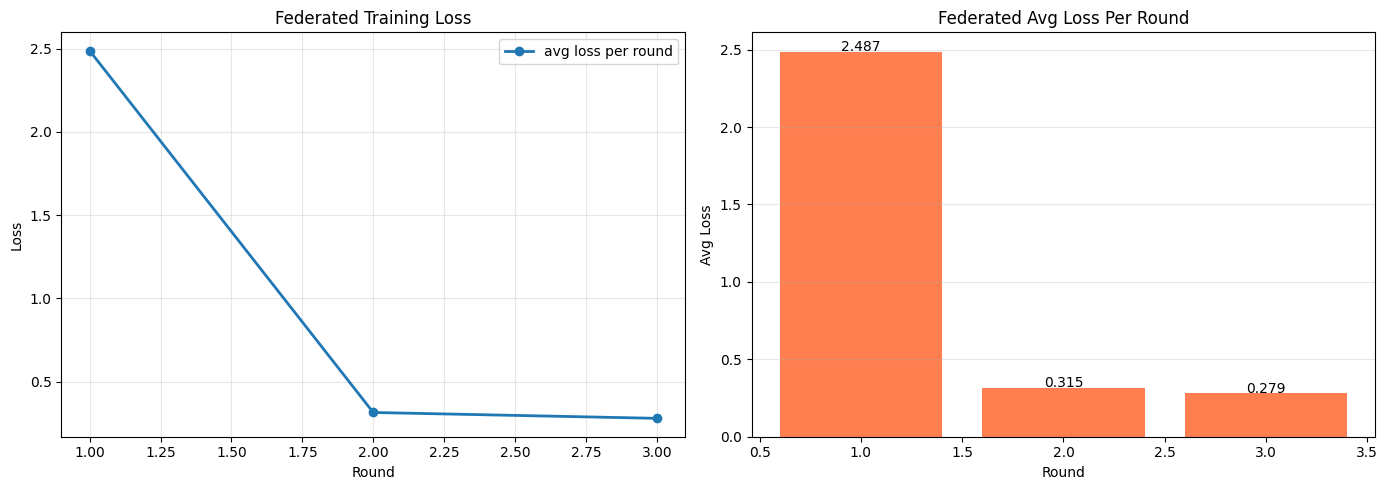

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plot saved to Drive.


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import json
from huggingface_hub import hf_hub_download

_repo  = CONFIG.get('repo_id', REPO_ID)
_token = CONFIG.get('hf_token', os.environ.get('HF_TOKEN', ''))

# Load federated loss from Hub
_state_path = hf_hub_download(repo_id=_repo, filename='aggregator_state.json', token=_token)
with open(_state_path) as f:
    agg_state = json.load(f)

history = agg_state.get('history', [])
federated_round_losses = [
    sum(h['node_losses'].values()) / len(h['node_losses'])
    for h in history if h.get('node_losses')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — no step-level history available for federated, show per-round as line
axes[0].plot(range(1, len(federated_round_losses) + 1), federated_round_losses,
             marker='o', linewidth=2, label='avg loss per round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].set_title('Federated Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right — avg loss per round bar chart
axes[1].bar(range(1, len(federated_round_losses) + 1), federated_round_losses, color='coral')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Avg Loss')
axes[1].set_title('Federated Avg Loss Per Round')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(federated_round_losses):
    axes[1].text(i+1, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
LOCAL_PLOT = '/content/federated_training_plots.png'
plt.savefig(LOCAL_PLOT, dpi=150)
plt.show()

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import shutil
shutil.copy(LOCAL_PLOT, '/content/drive/MyDrive/federated_training_plots.png')
print('Plot saved to Drive.')

Federated round losses: [2.4870486342410247, 0.3145843409001827, 0.27930037533243496]


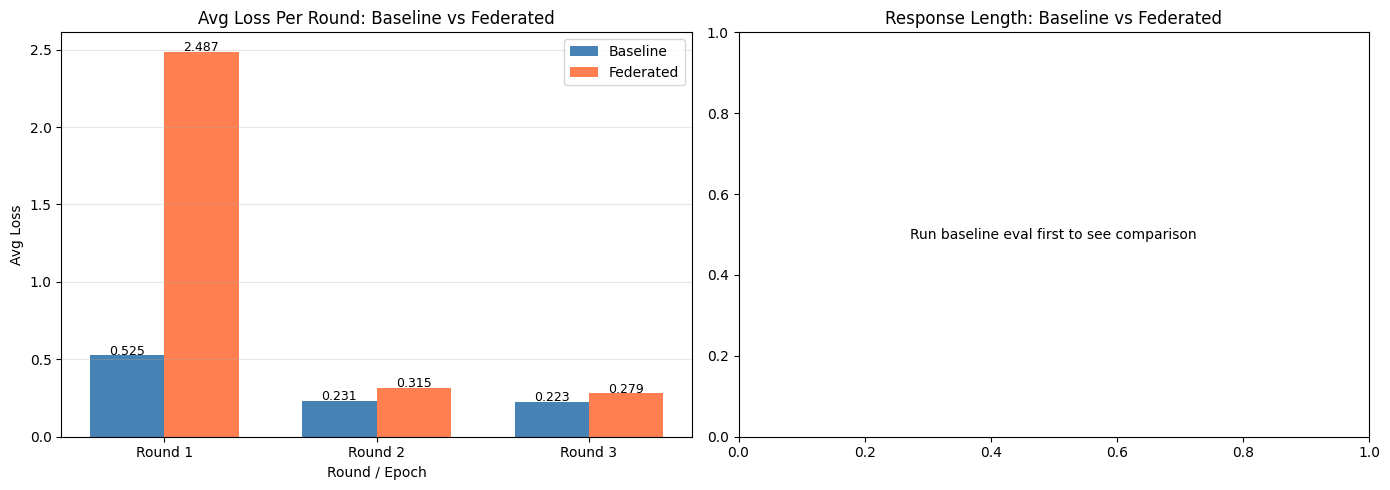

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plot saved to Drive.


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import json
from huggingface_hub import hf_hub_download

_repo  = CONFIG.get('repo_id', REPO_ID)
_token = CONFIG.get('hf_token', os.environ.get('HF_TOKEN', ''))

# Load federated loss from Hub
_state_path = hf_hub_download(repo_id=_repo, filename='aggregator_state.json', token=_token)
with open(_state_path) as f:
    agg_state = json.load(f)

history = agg_state.get('history', [])
federated_round_losses = [
    sum(h['node_losses'].values()) / len(h['node_losses'])
    for h in history if h.get('node_losses')
]
print(f'Federated round losses: {federated_round_losses}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — loss per round comparison
n_base = len(round_avgs)
n_fed  = len(federated_round_losses)
n      = max(n_base, n_fed)
width  = 0.35

if n_base > 0:
    axes[0].bar(
        [i - width/2 for i in range(n_base)],
        round_avgs, width, label='Baseline', color='steelblue'
    )
    for i, v in enumerate(round_avgs):
        axes[0].text(i - width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

if n_fed > 0:
    axes[0].bar(
        [i + width/2 for i in range(n_fed)],
        federated_round_losses, width, label='Federated', color='coral'
    )
    for i, v in enumerate(federated_round_losses):
        axes[0].text(i + width/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_xticks(list(range(n)))
axes[0].set_xticklabels([f'Round {i+1}' for i in range(n)])
axes[0].set_xlabel('Round / Epoch')
axes[0].set_ylabel('Avg Loss')
axes[0].set_title('Avg Loss Per Round: Baseline vs Federated')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Right — response length comparison
short_labels = ['Photosynthesis', 'Exercise', 'Prime fn', 'Capital', 'Relativity']
try:
    baseline_lens  = [len(r.split()) for r in baseline_responses]
    federated_lens = [len(r.split()) for r in federated_responses]
    x = list(range(len(short_labels)))
    axes[1].bar([i - width/2 for i in x], baseline_lens,  width, label='Baseline',  color='steelblue')
    axes[1].bar([i + width/2 for i in x], federated_lens, width, label='Federated', color='coral')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(short_labels, rotation=15, ha='right')
    axes[1].set_ylabel('Response length (words)')
    axes[1].set_title('Response Length: Baseline vs Federated')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
except NameError:
    axes[1].text(0.5, 0.5, 'Run baseline eval first to see comparison',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Response Length: Baseline vs Federated')

plt.tight_layout()
LOCAL_PLOT = '/content/federated_plots.png'
plt.savefig(LOCAL_PLOT, dpi=150)
plt.show()

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import shutil
shutil.copy(LOCAL_PLOT, '/content/drive/MyDrive/federated_plots.png')
print('Plot saved to Drive.')